In [8]:
import os
import cv2
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [9]:
class PreCroppedPatchDataset(Dataset):
    def __init__(self, split_dir, mask_base_dir):
        self.img_dir = split_dir
        self.fs_dir = os.path.join(mask_base_dir, 'fastsam')
        self.gt_dir = os.path.join(mask_base_dir, 'gt')
        self.img_files = [f for f in os.listdir(self.img_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        mask_name = img_name.replace('.jpg', '.png')
        
        img = cv2.imread(os.path.join(self.img_dir, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        fs_mask = cv2.imread(os.path.join(self.fs_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        gt_mask = cv2.imread(os.path.join(self.gt_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        
        img_tensor = torch.from_numpy(img.astype(np.float32) / 255.0).permute(2, 0, 1)
        fs_tensor = torch.from_numpy((fs_mask > 127).astype(np.float32)).unsqueeze(0)
        gt_tensor = torch.from_numpy((gt_mask > 127).astype(np.float32)).unsqueeze(0)
        
        return img_tensor, fs_tensor, gt_tensor

In [10]:
class SoftBoundaryLoss(nn.Module):
    def __init__(self, blur_kernel=31):
        super().__init__()
        self.blur_kernel = blur_kernel

    def extract_boundary(self, mask):
        dilated = F.max_pool2d(mask, kernel_size=3, stride=1, padding=1)
        eroded = -F.max_pool2d(-mask, kernel_size=3, stride=1, padding=1)
        return dilated - eroded

    def forward(self, pred, target):
        gt_boundary = self.extract_boundary(target)
        
        soft_glow = F.avg_pool2d(
            gt_boundary,
            kernel_size=self.blur_kernel,
            stride=1,
            padding=self.blur_kernel // 2
        )
        soft_glow = soft_glow / (soft_glow.max() + 1e-6)
        weight_map = 0.2 + (4.8 * soft_glow)
        
        bce_loss = F.binary_cross_entropy(pred, target, reduction='none')
        weighted_loss = bce_loss * weight_map
        
        return weighted_loss.mean()

In [11]:
class ResBlock(nn.Module):
    def __init__(self, channels, dilation=1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=dilation, dilation=dilation)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)

    def forward(self, x):
        return x + self.conv2(self.relu(self.conv1(x)))


class IterativeBoundaryRefiner(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.img_stem = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        self.mask_stem = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        self.pre_loop = nn.Sequential(
            nn.Conv2d(24, 24, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        self.looper = nn.Sequential(
            ResBlock(24, dilation=1),
            ResBlock(24, dilation=2),
            ResBlock(24, dilation=4),
            nn.Conv2d(24, 1, 3, padding=1)
        )

    def forward(self, img, init_mask, iters=3):
        img_feats = self.img_stem(img)
        curr_logits = (init_mask - 0.5) * 2.0 

        for _ in range(iters):
            curr_mask = torch.sigmoid(curr_logits)
            mask_feats = self.mask_stem(curr_mask)
            
            x = torch.cat([img_feats, mask_feats], dim=1)
            x = self.pre_loop(x)
            delta = self.looper(x)
            
            curr_logits = curr_logits + delta
            
        return torch.sigmoid(curr_logits)

In [12]:
# ===== TRAINING =====

device = torch.device('cuda')
print("GPUs available:", torch.cuda.device_count())

model = IterativeBoundaryRefiner()

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

model = model.to(device)

criterion = SoftBoundaryLoss(blur_kernel=11)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# Dataset paths (your Kaggle path)
base_path = "/kaggle/input/datasets/deban9017/aip-proj/dat_patch"

train_dataset = PreCroppedPatchDataset(
    os.path.join(base_path, "train"),
    os.path.join(base_path, "train_masks")
)

train_loader = DataLoader(
    train_dataset,
    batch_size=96,          # ↑ increase for multi-GPU
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_idx, (imgs, fs_masks, gt_masks) in enumerate(train_loader):
        imgs = imgs.to(device)
        fs_masks = fs_masks.to(device)
        gt_masks = gt_masks.to(device)

        optimizer.zero_grad()

        iters = random.randint(2, 5)
        refined_masks = model(imgs, fs_masks, iters)

        loss = criterion(refined_masks, gt_masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 20 == 0:
            print(f"Epoch [{epoch}/{epochs}] Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    print(f"--- Epoch {epoch} Avg Loss: {avg_loss:.4f} ---")

    scheduler.step(avg_loss)

    # ✅ correct save for DataParallel
    save_path = f"/kaggle/working/refiner_epoch_{epoch}.pth"
    if isinstance(model, nn.DataParallel):
        torch.save(model.module.state_dict(), save_path)
    else:
        torch.save(model.state_dict(), save_path)

GPUs available: 2
Epoch [0/10] Batch [0/42] Loss: 0.1308
Epoch [0/10] Batch [20/42] Loss: 0.0865
Epoch [0/10] Batch [40/42] Loss: 0.0841
--- Epoch 0 Avg Loss: 0.0911 ---
Epoch [1/10] Batch [0/42] Loss: 0.0793
Epoch [1/10] Batch [20/42] Loss: 0.0796
Epoch [1/10] Batch [40/42] Loss: 0.0663
--- Epoch 1 Avg Loss: 0.0775 ---
Epoch [2/10] Batch [0/42] Loss: 0.0815
Epoch [2/10] Batch [20/42] Loss: 0.0820
Epoch [2/10] Batch [40/42] Loss: 0.0706
--- Epoch 2 Avg Loss: 0.0727 ---
Epoch [3/10] Batch [0/42] Loss: 0.0771
Epoch [3/10] Batch [20/42] Loss: 0.0683
Epoch [3/10] Batch [40/42] Loss: 0.0664
--- Epoch 3 Avg Loss: 0.0687 ---
Epoch [4/10] Batch [0/42] Loss: 0.0681
Epoch [4/10] Batch [20/42] Loss: 0.0546
Epoch [4/10] Batch [40/42] Loss: 0.0741
--- Epoch 4 Avg Loss: 0.0656 ---
Epoch [5/10] Batch [0/42] Loss: 0.0665
Epoch [5/10] Batch [20/42] Loss: 0.0604
Epoch [5/10] Batch [40/42] Loss: 0.0564
--- Epoch 5 Avg Loss: 0.0667 ---
Epoch [6/10] Batch [0/42] Loss: 0.0651
Epoch [6/10] Batch [20/42] Loss

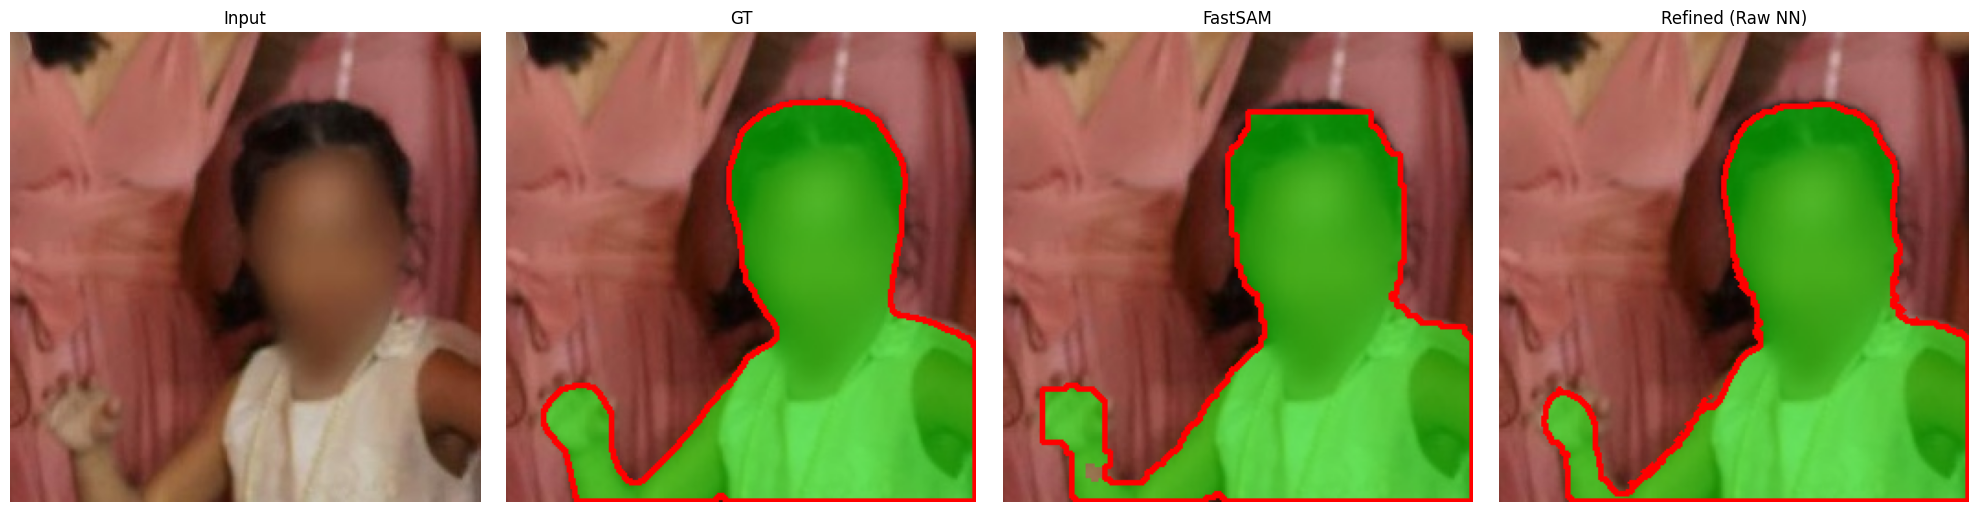

In [35]:
# ===== CLEAR GPU MEMORY =====
import gc
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

gc.collect()
torch.cuda.empty_cache()

# ===== TEST / VISUALIZATION =====

def create_overlay(img_base, mask, mask_color=(0, 255, 0)):
    mask_bin = (mask > 0.5).astype(np.uint8)
    color_layer = np.zeros_like(img_base)
    color_layer[:] = mask_color
    
    alpha = mask_bin[..., None] * 0.5 
    overlay = (img_base * (1 - alpha) + color_layer * alpha).astype(np.uint8)
    
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (255, 0, 0), 2)
    
    return overlay


device = torch.device('cuda:0')  # force single GPU

# ===== LOAD MODEL =====
# Make sure IterativeBoundaryRefiner is already defined/imported above this cell
model = IterativeBoundaryRefiner().to(device)
model.load_state_dict(torch.load("/kaggle/working/refiner_epoch_9.pth", map_location=device))
model.eval()


# ===== PATHS =====
base_path = "/kaggle/input/datasets/deban9017/aip-proj/dat_patch"

test_img_dir = os.path.join(base_path, "test")
test_fs_dir = os.path.join(base_path, "test_masks/fastsam")
test_gt_dir = os.path.join(base_path, "test_masks/gt")


# ===== RANDOM SAMPLE =====
test_imgs = [f for f in os.listdir(test_img_dir) if f.endswith('.jpg')]
img_name = random.choice(test_imgs)
mask_name = img_name.replace('.jpg', '.png')

img = cv2.imread(os.path.join(test_img_dir, img_name))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fs_mask = cv2.imread(os.path.join(test_fs_dir, mask_name), cv2.IMREAD_GRAYSCALE)
gt_mask = cv2.imread(os.path.join(test_gt_dir, mask_name), cv2.IMREAD_GRAYSCALE)

fs_bin = (fs_mask > 127).astype(np.uint8)
gt_bin = (gt_mask > 127).astype(np.uint8)


# ===== INFERENCE =====
img_t = torch.from_numpy(img_rgb.astype(np.float32) / 255.0)\
            .permute(2, 0, 1).unsqueeze(0).to(device)

fs_t = torch.from_numpy(fs_bin.astype(np.float32))\
           .unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    refined = model(img_t, fs_t, 4).squeeze().cpu().numpy()


# ===== POST-PROCESS =====
# Removed the union logic. Trusting the raw NN output to handle both growth and shrinkage.
refined_bin = (refined > 0.5).astype(np.uint8)


# ===== VISUALIZATION =====
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_rgb); axes[0].set_title("Input")
axes[1].imshow(create_overlay(img_rgb, gt_bin)); axes[1].set_title("GT")
axes[2].imshow(create_overlay(img_rgb, fs_bin)); axes[2].set_title("FastSAM")
axes[3].imshow(create_overlay(img_rgb, refined_bin)); axes[3].set_title("Refined (Raw NN)")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()